# Virginia Regional Economic Intelligence
## 05 — Regional Economic Opportunity Framework

### Objective

The previous notebooks developed two complementary views of Virginia's regional economy:

- **historical economic performance**, using QCEW employment growth, industry specialization, wages, and shift-share analysis;
- **forward-looking economic-development signals**, using structured VEDP investment announcements, job commitments, industry classifications, and document intelligence.

This notebook brings those components together into a transparent **Regional Economic Opportunity Framework**.

The goal is not simply to rank Virginia localities. Instead, the analysis evaluates the economic structure and trajectory of each locality across several dimensions:

- recent employment momentum;
- regional competitive performance;
- industry specialization;
- industrial diversity and concentration;
- emerging and declining sectors;
- recent announced investment;
- announced job creation;
- and the relationship between new projects and existing local industry strengths.

### Research Question

> **Which Virginia localities show the strongest combination of recent economic momentum, competitive industry performance, structural economic strengths, and forward-looking development signals—and where do the data suggest emerging opportunities or vulnerabilities?**

The framework is designed as an applied regional-economics decision-support tool. All component indicators remain visible so that the final results are interpretable rather than functioning as a black-box score.

### Analytical Approach

The analysis proceeds in five stages:

1. **Assemble locality-level indicators** from the validated outputs of Notebooks 03 and 04.
2. **Measure economic structure**, including specialization, sector concentration, and industrial diversity.
3. **Measure economic momentum**, using employment growth and shift-share competitive performance.
4. **Incorporate forward-looking signals**, including recent investment announcements, job commitments, and project diversity.
5. **Develop a transparent opportunity framework** that distinguishes different regional economic profiles rather than relying on a single unexplained ranking.

The final output will identify several types of regional opportunity, including:

- established economic leaders;
- emerging growth regions;
- specialized but vulnerable economies;
- diversification opportunities;
- and localities showing potential turnaround signals.

In [4]:
# Core imports and project paths
# ------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output tables: {OUTPUT_TABLES}")
print(f"Output figures: {OUTPUT_FIGURES}")

Project root: C:\Users\Chris\Documents\virginia-regional-economic-intelligence
Output tables: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\tables
Output figures: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures


## 1. Load Validated Regional Inputs

This notebook builds on the validated outputs created earlier in the project.

The main locality-level inputs are:

- matched employment growth from 2019 to 2025;
- aggregate regional competitive effects from shift-share analysis;
- top industry specialization by locality;
- full locality-industry location quotients;
- locality-industry shift-share results;
- and forward-looking VEDP project signals from the document-intelligence workflow.

These datasets provide the foundation for measuring regional momentum, structural strength, specialization, diversification, and forward-looking opportunity.

In [5]:
# Load validated outputs from Notebooks 03 and 04.
# ------------------------------------------------

locality_growth = pd.read_csv(
    OUTPUT_TABLES / "matched_locality_employment_growth_2019_2025.csv",
    dtype={"area_fips": str}
)

locality_competitive = pd.read_csv(
    OUTPUT_TABLES / "locality_competitive_effects_2019_2025.csv",
    dtype={"area_fips": str}
)

top_specialization = pd.read_csv(
    OUTPUT_TABLES / "top_industry_specialization_by_locality_2025.csv",
    dtype={"area_fips": str}
)

location_quotients = pd.read_csv(
    OUTPUT_TABLES / "location_quotients_2025.csv",
    dtype={"area_fips": str, "industry_code": str}
)

shift_share = pd.read_csv(
    OUTPUT_TABLES / "shift_share_locality_industry_2019_2025.csv",
    dtype={"area_fips": str, "industry_code": str}
)

vedp_locality_signals = pd.read_csv(
    OUTPUT_TABLES / "vedp_locality_project_signals.csv",
    dtype={"primary_area_fips": str}
)

vedp_project_industry = pd.read_csv(
    OUTPUT_TABLES / "vedp_project_industry_qcew_alignment.csv",
    dtype={
        "primary_area_fips": str,
        "project_industry_code": str
    }
)

print("Loaded tables:")
print(f" - locality_growth: {len(locality_growth):,} rows")
print(f" - locality_competitive: {len(locality_competitive):,} rows")
print(f" - top_specialization: {len(top_specialization):,} rows")
print(f" - location_quotients: {len(location_quotients):,} rows")
print(f" - shift_share: {len(shift_share):,} rows")
print(f" - vedp_locality_signals: {len(vedp_locality_signals):,} rows")
print(f" - vedp_project_industry: {len(vedp_project_industry):,} rows")

Loaded tables:
 - locality_growth: 133 rows
 - locality_competitive: 133 rows
 - top_specialization: 132 rows
 - location_quotients: 1,569 rows
 - shift_share: 1,459 rows
 - vedp_locality_signals: 45 rows
 - vedp_project_industry: 83 rows


## 2. Build the Locality-Level Analytical Base

The opportunity framework begins with all 133 Virginia localities represented in the historical QCEW analysis.

Forward-looking VEDP project activity is then added where available.

This ensures that localities with no recent project announcement remain in the analysis rather than disappearing from the comparison.

Missing VEDP activity is interpreted as **no resolved project signal observed in the current document window**, not as missing historical economic data.

In [6]:
# Build the core locality-level analytical dataset.
# -------------------------------------------------
# Start with the full historical locality universe and then
# merge in forward-looking project signals where available.

regional_base = (
    locality_growth[
        [
            "area_fips",
            "locality_name",
            "matched_employment_2019",
            "matched_employment_2025",
            "employment_change",
            "employment_growth_pct"
        ]
    ]
    .merge(
        locality_competitive[
            [
                "area_fips",
                "total_regional_competitive_effect"
            ]
        ],
        on="area_fips",
        how="left",
        validate="one_to_one"
    )
    .merge(
        vedp_locality_signals[
            [
                "primary_area_fips",
                "announced_project_count",
                "total_announced_investment_usd",
                "total_announced_jobs",
                "distinct_strategic_themes"
            ]
        ],
        left_on="area_fips",
        right_on="primary_area_fips",
        how="left",
        validate="one_to_one"
    )
)

# Remove the duplicate project-side FIPS field.
regional_base = regional_base.drop(
    columns="primary_area_fips"
)

# Localities without a resolved VEDP announcement receive zero
# project counts and zero observed forward-looking commitments.
zero_fill_columns = [
    "announced_project_count",
    "total_announced_investment_usd",
    "total_announced_jobs",
    "distinct_strategic_themes"
]

regional_base[zero_fill_columns] = (
    regional_base[zero_fill_columns]
    .fillna(0)
)

print(f"Localities in analytical base: {len(regional_base):,}")

print(
    "Localities with at least one resolved VEDP project:",
    (regional_base["announced_project_count"] > 0).sum()
)

print(
    "Localities with no resolved VEDP project:",
    (regional_base["announced_project_count"] == 0).sum()
)

Localities in analytical base: 133
Localities with at least one resolved VEDP project: 45
Localities with no resolved VEDP project: 88


## 3. Measure Industry Concentration and Diversification

Regional economic resilience depends partly on how concentrated or diversified a locality's employment base is.

A locality dominated by only a few industries may benefit from strong specialization, but it can also be more exposed to sector-specific shocks.

To measure this structure, the analysis uses a Herfindahl-Hirschman Index (HHI) based on 2025 published industry employment shares.

The index is calculated as:

$$
HHI = \sum_{i=1}^{N} s_i^2
$$

where:

- \(s_i\) is the employment share of industry \(i\) within the locality;
- \(N\) is the number of published industries in that locality.

Interpretation:

- **higher HHI** = more concentrated employment structure;
- **lower HHI** = more diversified employment structure.

A complementary diversification score is also created as:

$$
Diversification = 1 - HHI
$$

so that higher values consistently represent a broader and more diversified industry structure.

In [7]:
# Calculate locality-level industry concentration using 2025
# published employment shares from the location-quotient table.
# ------------------------------------------------------------

industry_structure = (
    location_quotients[
        [
            "area_fips",
            "locality_name",
            "industry_code",
            "industry_title",
            "local_industry_share"
        ]
    ]
    .dropna(
        subset=["local_industry_share"]
    )
    .copy()
)

# Herfindahl-Hirschman Index:
# sum of squared industry employment shares within each locality.
locality_hhi = (
    industry_structure
    .assign(
        squared_share=lambda df:
            df["local_industry_share"] ** 2
    )
    .groupby(
        [
            "area_fips",
            "locality_name"
        ],
        as_index=False
    )
    .agg(
        industry_hhi=(
            "squared_share",
            "sum"
        ),
        published_industry_count=(
            "industry_code",
            "nunique"
        )
    )
)

# Convert concentration into a more intuitive diversification score.
# Higher values indicate a more diversified published industry structure.
locality_hhi["diversification_score_raw"] = (
    1 - locality_hhi["industry_hhi"]
)

locality_hhi.sort_values(
    "industry_hhi",
    ascending=False
).head(10)

,area_fips,locality_name,industry_hhi,published_industry_count,diversification_score_raw
22,51045,Craig County,1.000000,1,0.000000
97,51530,Buena Vista city,0.640883,3,0.359117
106,51620,Franklin city,0.547257,5,0.452743
10,51021,Bland County,0.525433,5,0.474567
101,51580,Covington city,0.429148,6,0.570852
8,51017,Bath County,0.426055,3,0.573945
86,51181,Surry County,0.401806,3,0.598194
80,51169,Scott County,0.392093,7,0.607907
44,51091,Highland County,0.384059,4,0.615941
103,51595,Emporia city,0.355983,6,0.644017


In [8]:
# Inspect the most diversified localities based on published
# 2025 industry employment shares.
# ----------------------------------------------------------

locality_hhi.sort_values(
    "industry_hhi",
    ascending=True
).head(10)

,area_fips,locality_name,industry_hhi,published_industry_count,diversification_score_raw
99,51550,Chesapeake city,0.089100,20,0.910900
20,51041,Chesterfield County,0.094297,20,0.905703
124,51760,Richmond city,0.095574,20,0.904426
42,51087,Henrico County,0.096759,15,0.903241
52,51107,Loudoun County,0.098668,16,0.901332
1,51003,Albemarle County,0.101251,20,0.898749
9,51019,Bedford County,0.103408,16,0.896592
90,51191,Washington County,0.105065,20,0.894935
98,51540,Charlottesville city,0.105899,16,0.894101
46,51095,James City County,0.106604,16,0.893396


In [9]:
# Inspect coverage of published industries by locality.
# ----------------------------------------------------
# This helps us choose a minimum-sector threshold for using
# the diversification measure reliably.

published_sector_coverage = (
    locality_hhi["published_industry_count"]
    .value_counts()
    .sort_index()
    .rename_axis("published_industry_count")
    .reset_index(name="locality_count")
)

published_sector_coverage

,published_industry_count,locality_count
0,1,1
1,3,3
2,4,1
3,5,6
4,6,5
5,7,8
6,8,4
7,9,9
8,10,11
9,11,10


### 3.1 Diversification Coverage Threshold

QCEW publication suppression creates an important limitation for measuring local industry diversification.

For some smaller localities, only a small number of industries have published employment values. Calculating concentration from these incomplete industry profiles can make an economy appear much more concentrated than it actually is.

To reduce this bias, the diversification measure is considered sufficiently reliable only when a locality has employment data published for at least **10 broad industries**.

This threshold retains 96 of Virginia's 133 localities while excluding observations where industry coverage is too limited for a meaningful comparison.

Localities below the threshold are **not interpreted as poorly diversified**. Instead, their diversification measure is treated as unavailable.

In [10]:
# Apply a minimum published-industry threshold to the
# diversification measure.
# ----------------------------------------------------

MIN_PUBLISHED_INDUSTRIES = 10

locality_hhi["diversification_coverage_eligible"] = (
    locality_hhi["published_industry_count"]
    >= MIN_PUBLISHED_INDUSTRIES
)

# Retain the diversification measure only where industry
# publication coverage is sufficiently broad.
locality_hhi["diversification_score"] = np.where(
    locality_hhi["diversification_coverage_eligible"],
    locality_hhi["diversification_score_raw"],
    np.nan
)

print(
    "Localities with reliable diversification measure:",
    locality_hhi["diversification_score"].notna().sum()
)

print(
    "Localities excluded because of limited industry coverage:",
    locality_hhi["diversification_score"].isna().sum()
)

print(
    "Coverage rate:",
    f"{locality_hhi['diversification_score'].notna().mean():.1%}"
)

Localities with reliable diversification measure: 96
Localities excluded because of limited industry coverage: 37
Coverage rate: 72.2%


## 4. Add Structural Economic Indicators

The locality-level analytical base is now expanded with measures of economic structure.

For each locality, the framework adds:

- industry concentration (HHI);
- diversification score;
- number of published industries;
- diversification-coverage eligibility;
- and the locality's strongest observed industry specialization.

These measures help distinguish broad-based economies from places that are more dependent on a small number of sectors.

In [11]:
# Merge structural economic indicators into the regional base.
# ------------------------------------------------------------

regional_base = (
    regional_base
    .merge(
        locality_hhi[
            [
                "area_fips",
                "industry_hhi",
                "published_industry_count",
                "diversification_score",
                "diversification_coverage_eligible"
            ]
        ],
        on="area_fips",
        how="left",
        validate="one_to_one"
    )
    .merge(
        top_specialization[
            [
                "area_fips",
                "industry_code",
                "industry_title",
                "location_quotient"
            ]
        ],
        on="area_fips",
        how="left",
        validate="one_to_one",
        suffixes=("", "_top_specialization")
    )
)

print(f"Localities after structural merge: {len(regional_base):,}")

print(
    "Localities with diversification score:",
    regional_base["diversification_score"].notna().sum()
)

print(
    "Localities with top specialization identified:",
    regional_base["industry_title"].notna().sum()
)

Localities after structural merge: 133
Localities with diversification score: 96
Localities with top specialization identified: 132


## 5. Measure Regional Economic Momentum

Economic structure describes what a locality's economy looks like. The next dimension measures how that economy has recently performed.

Two indicators are used:

- **Employment growth (2019–2025):** whether the locality's matched private-sector employment base expanded or contracted;
- **Regional competitive effect:** whether the locality gained or lost employment beyond what would be expected from statewide and industry growth patterns.

These measures capture different aspects of momentum:

- employment growth reflects the locality's overall direction;
- the competitive effect reflects whether local performance exceeded or lagged broader structural trends.

Because the indicators are measured on different scales, they will later be standardized before being combined into the opportunity framework.

In [12]:
# Validate the core economic-momentum indicators.
# -----------------------------------------------

momentum_summary = pd.DataFrame({
    "metric": [
        "Localities",
        "Employment growth values available",
        "Competitive effect values available",
        "Median employment growth",
        "Minimum employment growth",
        "Maximum employment growth",
        "Median competitive effect",
        "Minimum competitive effect",
        "Maximum competitive effect"
    ],
    "value": [
        len(regional_base),
        regional_base["employment_growth_pct"].notna().sum(),
        regional_base["total_regional_competitive_effect"].notna().sum(),
        regional_base["employment_growth_pct"].median(),
        regional_base["employment_growth_pct"].min(),
        regional_base["employment_growth_pct"].max(),
        regional_base["total_regional_competitive_effect"].median(),
        regional_base["total_regional_competitive_effect"].min(),
        regional_base["total_regional_competitive_effect"].max()
    ]
})

momentum_summary

,metric,value
0,Localities,133.000000
1,Employment growth values available,133.000000
2,Competitive effect values available,133.000000
3,Median employment growth,0.005506
4,Minimum employment growth,-0.386667
5,Maximum employment growth,0.446213
6,Median competitive effect,-12.490487
7,Minimum competitive effect,-7248.483620
8,Maximum competitive effect,16428.778522


### 5.1 Scale-Adjusted Competitive Performance

The raw regional competitive effect is measured in jobs.

This creates an important scale issue: large localities can produce much larger positive or negative competitive effects simply because their employment bases are larger.

To make competitive performance more comparable across Virginia localities, the competitive effect is normalized by matched 2019 employment:

$$
Competitive\ Effect\ Rate =
\frac{Regional\ Competitive\ Effect}
{Matched\ Employment_{2019}}
$$

This converts the shift-share result into a relative measure of competitive performance.

Interpretation:

- **positive values** indicate employment gains beyond what statewide and industry trends would predict;
- **negative values** indicate underperformance relative to those broader trends;
- larger absolute values indicate stronger local competitive effects relative to the locality's starting employment base.

In [13]:
# Convert the absolute regional competitive effect into a
# scale-adjusted rate relative to the locality's 2019 employment base.
# --------------------------------------------------------------------

regional_base["competitive_effect_rate"] = (
    regional_base["total_regional_competitive_effect"]
    / regional_base["matched_employment_2019"]
)

competitive_rate_summary = pd.DataFrame({
    "metric": [
        "Localities",
        "Median competitive effect rate",
        "Minimum competitive effect rate",
        "Maximum competitive effect rate"
    ],
    "value": [
        len(regional_base),
        regional_base["competitive_effect_rate"].median(),
        regional_base["competitive_effect_rate"].min(),
        regional_base["competitive_effect_rate"].max()
    ]
})

competitive_rate_summary

,metric,value
0,Localities,133.000000
1,Median competitive effect rate,-0.009333
2,Minimum competitive effect rate,-0.475912
3,Maximum competitive effect rate,0.389927


In [14]:
# Inspect the strongest and weakest scale-adjusted
# competitive-performance localities.
# ----------------------------------------------

strongest_competitive_rates = (
    regional_base[
        [
            "area_fips",
            "locality_name",
            "matched_employment_2019",
            "total_regional_competitive_effect",
            "competitive_effect_rate"
        ]
    ]
    .sort_values(
        "competitive_effect_rate",
        ascending=False
    )
    .head(10)
)

weakest_competitive_rates = (
    regional_base[
        [
            "area_fips",
            "locality_name",
            "matched_employment_2019",
            "total_regional_competitive_effect",
            "competitive_effect_rate"
        ]
    ]
    .sort_values(
        "competitive_effect_rate",
        ascending=True
    )
    .head(10)
)

print("Strongest competitive-effect rates:")
display(strongest_competitive_rates)

print("\nWeakest competitive-effect rates:")
display(weakest_competitive_rates)

Strongest competitive-effect rates:


,area_fips,locality_name,matched_employment_2019,total_regional_competitive_effect,competitive_effect_rate
128,51800,Suffolk city,24625.0,9601.941198,0.389927
44,51091,Highland County,50.0,16.413724,0.328274
18,51036,Charles City County,900.0,263.256193,0.292507
85,51179,Stafford County,25099.0,6880.464922,0.274133
48,51099,King George County,4342.0,1046.238026,0.240958
112,51678,Lexington city,370.0,89.083179,0.240765
83,51175,Southampton County,1040.0,226.094151,0.217398
96,51520,Bristol city,4888.0,990.858350,0.202712
69,51145,Powhatan County,4513.0,890.697148,0.197363
10,51021,Bland County,727.0,140.045974,0.192635



Weakest competitive-effect rates:


,area_fips,locality_name,matched_employment_2019,total_regional_competitive_effect,competitive_effect_rate
86,51181,Surry County,225.0,-107.080235,-0.475912
54,51111,Lunenburg County,1122.0,-360.665694,-0.321449
39,51081,Greensville County,1731.0,-497.528500,-0.287423
26,51053,Dinwiddie County,4984.0,-1118.936030,-0.224506
13,51027,Buchanan County,2661.0,-527.669940,-0.198298
12,51025,Brunswick County,1490.0,-286.697242,-0.192414
45,51093,Isle of Wight County,8062.0,-1476.633054,-0.183160
17,51035,Carroll County,2642.0,-463.894870,-0.175585
92,51195,Wise County,6092.0,-992.183533,-0.162867
131,51830,Williamsburg city,2468.0,-372.835059,-0.151068


### 5.2 Limit the Influence of Extreme Competitive-Effect Rates

Normalizing the regional competitive effect by 2019 employment improves comparability across localities, but very small employment bases can still generate unusually large percentage effects.

For example, a modest absolute employment change can produce a very large competitive-effect rate in a small locality.

To reduce the influence of these extreme observations without removing them from the analysis, the competitive-effect rate is **winsorized at the 5th and 95th percentiles**.

Values below the 5th percentile are set equal to the 5th-percentile value, and values above the 95th percentile are set equal to the 95th-percentile value.

This preserves the relative performance of most localities while preventing extreme observations from dominating the composite momentum framework.

In [15]:
# Winsorize the scale-adjusted competitive-effect rate.
# -----------------------------------------------------

competitive_lower = (
    regional_base["competitive_effect_rate"]
    .quantile(0.05)
)

competitive_upper = (
    regional_base["competitive_effect_rate"]
    .quantile(0.95)
)

regional_base["competitive_effect_rate_winsorized"] = (
    regional_base["competitive_effect_rate"]
    .clip(
        lower=competitive_lower,
        upper=competitive_upper
    )
)

print(
    f"5th percentile: {competitive_lower:.4f}"
)

print(
    f"95th percentile: {competitive_upper:.4f}"
)

print(
    "Observations capped at lower bound:",
    (
        regional_base["competitive_effect_rate"]
        < competitive_lower
    ).sum()
)

print(
    "Observations capped at upper bound:",
    (
        regional_base["competitive_effect_rate"]
        > competitive_upper
    ).sum()
)

5th percentile: -0.1786
95th percentile: 0.2086
Observations capped at lower bound: 7
Observations capped at upper bound: 7


### 5.3 Build a Regional Economic Momentum Score

Employment growth and competitive performance capture different dimensions of recent regional economic momentum.

To combine them into a comparable measure, both indicators are standardized using z-scores:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- \(x\) is the locality's observed value;
- \(\mu\) is the statewide mean;
- \(\sigma\) is the statewide standard deviation.

The two standardized indicators are then given equal weight:

$$
Momentum\ Score =
\frac{
z_{Employment\ Growth}
+
z_{Competitive\ Effect}
}{2}
$$

A higher momentum score indicates a locality that has both grown faster and outperformed broader statewide and industry trends.

The component scores remain visible so that the final framework is fully interpretable.

In [16]:
# Standardize recent employment growth and competitive performance.
# ---------------------------------------------------------------

def zscore(series):
    """
    Standardize a pandas Series using the sample mean
    and standard deviation.
    """
    return (
        series - series.mean()
    ) / series.std()


regional_base["employment_growth_z"] = zscore(
    regional_base["employment_growth_pct"]
)

regional_base["competitive_effect_z"] = zscore(
    regional_base["competitive_effect_rate_winsorized"]
)


# Equal-weight momentum score.
regional_base["economic_momentum_score"] = (
    regional_base[
        [
            "employment_growth_z",
            "competitive_effect_z"
        ]
    ]
    .mean(axis=1)
)

In [17]:
# Review the highest and lowest regional economic momentum scores.

momentum_ranking = (
    regional_base[
        [
            "area_fips",
            "locality_name",
            "employment_growth_pct",
            "competitive_effect_rate",
            "competitive_effect_rate_winsorized",
            "employment_growth_z",
            "competitive_effect_z",
            "economic_momentum_score"
        ]
    ]
    .sort_values(
        "economic_momentum_score",
        ascending=False
    )
)

print("Highest momentum localities:")
display(
    momentum_ranking.head(10)
)

print("\nLowest momentum localities:")
display(
    momentum_ranking.tail(10)
)

Highest momentum localities:


,area_fips,locality_name,employment_growth_pct,competitive_effect_rate,competitive_effect_rate_winsorized,employment_growth_z,competitive_effect_z,economic_momentum_score
128,51800,Suffolk city,0.446213,0.389927,0.208587,3.296905,2.033707,2.665306
44,51091,Highland County,0.440000,0.328274,0.208587,3.249796,2.033707,2.641751
18,51036,Charles City County,0.408889,0.292507,0.208587,3.013911,2.033707,2.523809
85,51179,Stafford County,0.320092,0.274133,0.208587,2.340653,2.033707,2.187180
48,51099,King George County,0.258867,0.240958,0.208587,1.876439,2.033707,1.955073
69,51145,Powhatan County,0.248615,0.197363,0.197363,1.798710,1.925571,1.862140
96,51520,Bristol city,0.222177,0.202712,0.202712,1.598253,1.977112,1.787683
112,51678,Lexington city,0.213514,0.240765,0.208587,1.532568,2.033707,1.783138
83,51175,Southampton County,0.201923,0.217398,0.208587,1.444689,2.033707,1.739198
10,51021,Bland County,0.158184,0.192635,0.192635,1.113061,1.880029,1.496545



Lowest momentum localities:


,area_fips,locality_name,employment_growth_pct,competitive_effect_rate,competitive_effect_rate_winsorized,employment_growth_z,competitive_effect_z,economic_momentum_score
67,51141,Patrick County,-0.165825,-0.143118,-0.143118,-1.343587,-1.354681,-1.349134
92,51195,Wise County,-0.152659,-0.162867,-0.162867,-1.243765,-1.544945,-1.394355
131,51830,Williamsburg city,-0.171799,-0.151068,-0.151068,-1.388883,-1.431271,-1.410077
13,51027,Buchanan County,-0.161218,-0.198298,-0.178615,-1.308655,-1.696665,-1.502660
45,51093,Isle of Wight County,-0.169437,-0.183160,-0.178615,-1.370973,-1.696665,-1.533819
12,51025,Brunswick County,-0.185235,-0.192414,-0.178615,-1.490755,-1.696665,-1.593710
17,51035,Carroll County,-0.198713,-0.175585,-0.175585,-1.592947,-1.667473,-1.630210
39,51081,Greensville County,-0.299249,-0.287423,-0.178615,-2.355213,-1.696665,-2.025939
54,51111,Lunenburg County,-0.313725,-0.321449,-0.178615,-2.464974,-1.696665,-2.080819
86,51181,Surry County,-0.386667,-0.475912,-0.178615,-3.018017,-1.696665,-2.357341


### 5.4 Limit the Influence of Extreme Employment Growth Rates

Employment growth is also expressed as a percentage of the locality's starting employment base.

As with the competitive-effect rate, very small localities can experience large percentage changes from relatively modest absolute employment movements.

To ensure that the momentum score reflects broad economic performance rather than extreme small-base effects, employment growth is also winsorized at the 5th and 95th percentiles.

Both momentum components are therefore treated consistently:

- employment growth is winsorized at the 5th and 95th percentiles;
- competitive-effect rate is winsorized at the 5th and 95th percentiles.

The resulting standardized indicators are then combined with equal weight.

In [18]:
# Winsorize employment growth using the same approach applied
# to the competitive-effect rate.
# -----------------------------------------------------------

growth_lower = (
    regional_base["employment_growth_pct"]
    .quantile(0.05)
)

growth_upper = (
    regional_base["employment_growth_pct"]
    .quantile(0.95)
)

regional_base["employment_growth_winsorized"] = (
    regional_base["employment_growth_pct"]
    .clip(
        lower=growth_lower,
        upper=growth_upper
    )
)

print(
    f"5th percentile: {growth_lower:.4f}"
)

print(
    f"95th percentile: {growth_upper:.4f}"
)

print(
    "Observations capped at lower bound:",
    (
        regional_base["employment_growth_pct"]
        < growth_lower
    ).sum()
)

print(
    "Observations capped at upper bound:",
    (
        regional_base["employment_growth_pct"]
        > growth_upper
    ).sum()
)

5th percentile: -0.1673
95th percentile: 0.2170
Observations capped at lower bound: 7
Observations capped at upper bound: 7


### 5.5 Final Regional Economic Momentum Score

With both momentum indicators adjusted for extreme small-base effects, the final momentum score is calculated from:

- winsorized employment growth;
- winsorized competitive-effect rate.

Each component is standardized using a z-score and given equal weight.

This produces a more stable measure of recent regional economic momentum while preserving the underlying direction of local performance.

In [19]:
# Rebuild the final momentum score using both winsorized components.
# ------------------------------------------------------------------

regional_base["employment_growth_z_final"] = zscore(
    regional_base["employment_growth_winsorized"]
)

regional_base["competitive_effect_z_final"] = zscore(
    regional_base["competitive_effect_rate_winsorized"]
)

regional_base["economic_momentum_score_final"] = (
    regional_base[
        [
            "employment_growth_z_final",
            "competitive_effect_z_final"
        ]
    ]
    .mean(axis=1)
)

In [20]:
# Review the revised strongest and weakest momentum localities.

momentum_ranking_final = (
    regional_base[
        [
            "area_fips",
            "locality_name",
            "matched_employment_2019",
            "employment_growth_pct",
            "employment_growth_winsorized",
            "competitive_effect_rate",
            "competitive_effect_rate_winsorized",
            "economic_momentum_score_final"
        ]
    ]
    .sort_values(
        "economic_momentum_score_final",
        ascending=False
    )
)

print("Highest final momentum localities:")
display(
    momentum_ranking_final.head(10)
)

print("\nLowest final momentum localities:")
display(
    momentum_ranking_final.tail(10)
)

Highest final momentum localities:


,area_fips,locality_name,matched_employment_2019,employment_growth_pct,employment_growth_winsorized,competitive_effect_rate,competitive_effect_rate_winsorized,economic_momentum_score_final
44,51091,Highland County,50.0,0.440000,0.216979,0.328274,0.208587,1.985258
48,51099,King George County,4342.0,0.258867,0.216979,0.240958,0.208587,1.985258
128,51800,Suffolk city,24625.0,0.446213,0.216979,0.389927,0.208587,1.985258
85,51179,Stafford County,25099.0,0.320092,0.216979,0.274133,0.208587,1.985258
18,51036,Charles City County,900.0,0.408889,0.216979,0.292507,0.208587,1.985258
112,51678,Lexington city,370.0,0.213514,0.213514,0.240765,0.208587,1.969096
96,51520,Bristol city,4888.0,0.222177,0.216979,0.202712,0.202712,1.956961
69,51145,Powhatan County,4513.0,0.248615,0.216979,0.197363,0.197363,1.931190
83,51175,Southampton County,1040.0,0.201923,0.201923,0.217398,0.208587,1.915041
10,51021,Bland County,727.0,0.158184,0.158184,0.192635,0.192635,1.634213



Lowest final momentum localities:


,area_fips,locality_name,matched_employment_2019,employment_growth_pct,employment_growth_winsorized,competitive_effect_rate,competitive_effect_rate_winsorized,economic_momentum_score_final
67,51141,Patrick County,2376.0,-0.165825,-0.165825,-0.143118,-0.143118,-1.494258
92,51195,Wise County,6092.0,-0.152659,-0.152659,-0.162867,-0.162867,-1.527988
131,51830,Williamsburg city,2468.0,-0.171799,-0.167270,-0.151068,-0.151068,-1.539292
13,51027,Buchanan County,2661.0,-0.161218,-0.161218,-0.198298,-0.178615,-1.643762
17,51035,Carroll County,2642.0,-0.198713,-0.167270,-0.175585,-0.175585,-1.657393
12,51025,Brunswick County,1490.0,-0.185235,-0.167270,-0.192414,-0.178615,-1.671988
45,51093,Isle of Wight County,8062.0,-0.169437,-0.167270,-0.183160,-0.178615,-1.671988
86,51181,Surry County,225.0,-0.386667,-0.167270,-0.475912,-0.178615,-1.671988
39,51081,Greensville County,1731.0,-0.299249,-0.167270,-0.287423,-0.178615,-1.671988
54,51111,Lunenburg County,1122.0,-0.313725,-0.167270,-0.321449,-0.178615,-1.671988


### 5.6 Establish a Minimum Employment Base for Statewide Momentum Rankings

The momentum score is calculated for all Virginia localities, but percentage-based indicators can remain sensitive to very small employment bases even after winsorization.

For example, a relatively small absolute employment change can produce a large growth rate in a locality with only a few hundred matched jobs.

To prevent very small labor markets from dominating statewide rankings, a minimum 2019 matched-employment threshold is applied **only for comparative ranking purposes**.

Localities below the threshold remain in the analytical dataset and retain their momentum scores. They are simply excluded from statements such as "highest-momentum localities statewide."

A threshold of **5,000 matched private-sector jobs in 2019** is used, consistent with the locality-ranking approach applied earlier in the project.

In [21]:
# Create a ranking-eligibility flag based on the locality's
# matched 2019 employment base.
# ---------------------------------------------------------

MIN_RANKING_EMPLOYMENT = 5_000

regional_base["momentum_ranking_eligible"] = (
    regional_base["matched_employment_2019"]
    >= MIN_RANKING_EMPLOYMENT
)

print(
    "Localities eligible for statewide momentum ranking:",
    regional_base["momentum_ranking_eligible"].sum()
)

print(
    "Localities retained but excluded from statewide ranking:",
    (~regional_base["momentum_ranking_eligible"]).sum()
)

Localities eligible for statewide momentum ranking: 65
Localities retained but excluded from statewide ranking: 68


In [22]:
# Review the highest-momentum localities among sufficiently
# large employment bases.

eligible_momentum_ranking = (
    regional_base[
        regional_base["momentum_ranking_eligible"]
    ]
    [
        [
            "area_fips",
            "locality_name",
            "matched_employment_2019",
            "employment_growth_pct",
            "competitive_effect_rate",
            "economic_momentum_score_final"
        ]
    ]
    .sort_values(
        "economic_momentum_score_final",
        ascending=False
    )
)

eligible_momentum_ranking.head(15)

,area_fips,locality_name,matched_employment_2019,employment_growth_pct,competitive_effect_rate,economic_momentum_score_final
85,51179,Stafford County,25099.0,0.320092,0.274133,1.985258
128,51800,Suffolk city,24625.0,0.446213,0.389927,1.985258
33,51069,Frederick County,25563.0,0.194813,0.152329,1.610882
104,51600,Fairfax city,16978.0,0.170691,0.154631,1.509474
130,51820,Waynesboro city,6500.0,0.134923,0.145144,1.296957
52,51107,Loudoun County,144351.0,0.164079,0.113811,1.282002
36,51075,Goochland County,7518.0,0.166534,0.102764,1.240232
71,51149,Prince George County,5880.0,0.185374,0.078797,1.212651
32,51067,Franklin County,10094.0,0.085100,0.092871,0.812785
7,51015,Augusta County,22368.0,0.119903,0.049573,0.766534


## 6. Measure Structural Economic Strength

Economic momentum captures recent performance, but regional opportunity also depends on the underlying structure of the local economy.

Two complementary structural indicators are used:

1. **Industry specialization strength**  
   The location quotient of the locality's strongest published industry indicates whether the locality has a distinctive economic cluster or comparative concentration.

2. **Industry diversification**  
   The diversification score measures how broadly employment is distributed across published industries.

These dimensions capture an important regional-economics tradeoff:

- specialization can support productivity, clustering, supplier networks, and workforce expertise;
- diversification can reduce exposure to industry-specific shocks.

The framework therefore treats specialization and diversification as complementary characteristics rather than assuming that either one is universally preferable.

In [23]:
# Inspect the distribution of each locality's strongest industry specialization.
# ------------------------------------------------------------------------------

specialization_summary = pd.DataFrame({
    "metric": [
        "Localities with top specialization",
        "Median top-industry LQ",
        "Minimum top-industry LQ",
        "Maximum top-industry LQ",
        "Top-industry LQ 90th percentile",
        "Top-industry LQ 95th percentile"
    ],
    "value": [
        regional_base["location_quotient"].notna().sum(),
        regional_base["location_quotient"].median(),
        regional_base["location_quotient"].min(),
        regional_base["location_quotient"].max(),
        regional_base["location_quotient"].quantile(0.90),
        regional_base["location_quotient"].quantile(0.95)
    ]
})

specialization_summary

,metric,value
0,Localities with top specialization,132.000000
1,Median top-industry LQ,3.888202
2,Minimum top-industry LQ,1.518634
3,Maximum top-industry LQ,207.332345
4,Top-industry LQ 90th percentile,14.557692
5,Top-industry LQ 95th percentile,44.097318


### 6.1 Transform Extreme Specialization Values

Top-industry location quotients are highly skewed.

Most localities have moderate specialization, but a small number have extremely large location quotients because a particular industry accounts for an unusually large share of published local employment.

Using raw location quotients directly would allow these extreme values to dominate the structural-strength framework.

To reduce this influence while preserving meaningful differences, the top-industry location quotient is transformed using:

$$
Specialization^{*} = \ln(1 + LQ)
$$

The transformed measure is then winsorized at the 5th and 95th percentiles.

This approach preserves the interpretation that higher values indicate stronger specialization while preventing a small number of extreme observations from overwhelming the analysis.

In [24]:
# Log-transform and winsorize top-industry specialization.
# --------------------------------------------------------

regional_base["specialization_log"] = np.log1p(
    regional_base["location_quotient"]
)

specialization_lower = (
    regional_base["specialization_log"]
    .quantile(0.05)
)

specialization_upper = (
    regional_base["specialization_log"]
    .quantile(0.95)
)

regional_base["specialization_log_winsorized"] = (
    regional_base["specialization_log"]
    .clip(
        lower=specialization_lower,
        upper=specialization_upper
    )
)

print(
    f"5th percentile (log LQ): {specialization_lower:.4f}"
)

print(
    f"95th percentile (log LQ): {specialization_upper:.4f}"
)

print(
    "Observations capped at lower bound:",
    (
        regional_base["specialization_log"]
        < specialization_lower
    ).sum()
)

print(
    "Observations capped at upper bound:",
    (
        regional_base["specialization_log"]
        > specialization_upper
    ).sum()
)

5th percentile (log LQ): 1.0834
95th percentile (log LQ): 3.7966
Observations capped at lower bound: 7
Observations capped at upper bound: 7


### 6.2 Build a Structural Economic Strength Score

Structural strength combines two complementary characteristics:

- **specialization strength**, which captures the presence of distinctive industry concentrations;
- **diversification**, which captures the breadth of the local employment base.

Both indicators are standardized before being combined.

The structural score is calculated only for localities with reliable diversification coverage. Localities without sufficient published-industry coverage remain in the dataset, but their structural score is treated as unavailable rather than estimated from incomplete information.

The score is defined as:

$$
Structural\ Strength =
\frac{
z_{Specialization}
+
z_{Diversification}
}{2}
$$

A higher value indicates a locality that combines strong industry specialization with a relatively broad economic base.

In [25]:
# Standardize specialization and diversification.
# -----------------------------------------------

regional_base["specialization_z"] = zscore(
    regional_base["specialization_log_winsorized"]
)

regional_base["diversification_z"] = zscore(
    regional_base["diversification_score"]
)


# Create structural strength only where diversification
# coverage is considered reliable.
regional_base["structural_strength_score"] = np.where(
    regional_base["diversification_coverage_eligible"],
    (
        regional_base["specialization_z"]
        + regional_base["diversification_z"]
    ) / 2,
    np.nan
)

In [26]:
# Review localities with the strongest structural economic profiles.

structural_ranking = (
    regional_base[
        regional_base["structural_strength_score"].notna()
    ]
    [
        [
            "area_fips",
            "locality_name",
            "industry_title",
            "location_quotient",
            "industry_hhi",
            "diversification_score",
            "specialization_z",
            "diversification_z",
            "structural_strength_score"
        ]
    ]
    .sort_values(
        "structural_strength_score",
        ascending=False
    )
)

structural_ranking.head(15)

,area_fips,locality_name,industry_title,location_quotient,industry_hhi,diversification_score,specialization_z,diversification_z,structural_strength_score
91,51193,Westmoreland County,"Agriculture, Forestry, Fishing and Hunting",64.928870,0.120636,0.879364,2.892211,0.789345,1.840778
36,51075,Goochland County,"Mining, Quarrying, and Oil and Gas Extraction",36.290040,0.120926,0.879074,2.637640,0.782662,1.710151
63,51133,Northumberland County,"Agriculture, Forestry, Fishing and Hunting",70.956550,0.157136,0.842864,2.892211,-0.051012,1.420600
1,51003,Albemarle County,"Agriculture, Forestry, Fishing and Hunting",13.118703,0.101251,0.898749,1.247435,1.235661,1.241548
53,51109,Louisa County,Utilities,109.160772,0.177403,0.822597,2.892211,-0.517628,1.187291
90,51191,Washington County,"Agriculture, Forestry, Fishing and Hunting",11.058495,0.105065,0.894935,1.021660,1.147843,1.084752
16,51033,Caroline County,Utilities,21.668852,0.145594,0.854406,1.925187,0.214719,1.069953
62,51131,Northampton County,"Agriculture, Forestry, Fishing and Hunting",207.332345,0.188129,0.811871,2.892211,-0.764570,1.063821
23,51047,Culpeper County,"Agriculture, Forestry, Fishing and Hunting",16.269507,0.132783,0.867217,1.535777,0.509677,1.022727
93,51197,Wythe County,"Mining, Quarrying, and Oil and Gas Extraction",51.934230,0.199031,0.800969,2.892211,-1.015581,0.938315


### 6.3 Measure the Breadth of Local Industry Strength

The maximum location quotient identifies a locality's strongest individual specialization, but it can overemphasize highly concentrated niche industries.

A more complete measure of regional structure considers the **breadth of specialization** across the local economy.

For each locality, the analysis therefore measures:

- the number of industries with a location quotient of at least 1.25;
- the number of those industries that also meet the employment-based ranking eligibility criteria used in Notebook 03.

This distinguishes a locality with one extreme specialization from a locality with several meaningful industry clusters.

The breadth measure will be evaluated alongside diversification rather than treating the single highest location quotient as a complete measure of structural strength.

In [27]:
# Measure the breadth of meaningful industry specialization by locality.
# ---------------------------------------------------------------------

specialization_breadth = (
    location_quotients
    .groupby(
        [
            "area_fips",
            "locality_name"
        ],
        as_index=False
    )
    .agg(
        specialized_industry_count=(
            "is_specialized",
            "sum"
        ),
        ranking_eligible_specialization_count=(
            "ranking_eligible_specialization",
            "sum"
        )
    )
)

specialization_breadth.sort_values(
    "ranking_eligible_specialization_count",
    ascending=False
).head(15)

,area_fips,locality_name,specialized_industry_count,ranking_eligible_specialization_count
98,51540,Charlottesville city,8,8
124,51760,Richmond city,8,8
16,51033,Caroline County,8,7
118,51710,Norfolk city,7,7
105,51610,Falls Church city,8,7
90,51191,Washington County,9,7
6,51013,Arlington County,7,7
50,51103,Lancaster County,10,7
127,51790,Staunton city,7,7
1,51003,Albemarle County,8,7


### 6.4 Final Structural Economic Strength Score

The initial structural score relied too heavily on the locality's single highest location quotient, which could overstate the strength of economies dominated by one unusually concentrated industry.

The final structural framework therefore uses two broader measures:

- **Specialization breadth:** the number of industries that meet the project's ranking-eligible specialization criteria;
- **Diversification:** the breadth of the locality's published industry employment structure.

These indicators capture two complementary forms of structural strength:

- multiple meaningful industry clusters;
- and a broad economic base.

Both measures are standardized and combined with equal weight.

The maximum location quotient remains available as a descriptive indicator but does not directly determine the structural-strength score.

In [28]:
# Merge specialization breadth into the regional analytical base.
# --------------------------------------------------------------

regional_base = (
    regional_base
    .merge(
        specialization_breadth[
            [
                "area_fips",
                "specialized_industry_count",
                "ranking_eligible_specialization_count"
            ]
        ],
        on="area_fips",
        how="left",
        validate="one_to_one"
    )
)

In [29]:
# Standardize specialization breadth and diversification.
# -------------------------------------------------------

regional_base["specialization_breadth_z"] = zscore(
    regional_base["ranking_eligible_specialization_count"]
)

regional_base["diversification_z_final"] = zscore(
    regional_base["diversification_score"]
)

# Final structural score is calculated only where the
# diversification measure has reliable publication coverage.
regional_base["structural_strength_score_final"] = np.where(
    regional_base["diversification_coverage_eligible"],
    (
        regional_base["specialization_breadth_z"]
        + regional_base["diversification_z_final"]
    ) / 2,
    np.nan
)

In [30]:
# Review localities with the strongest final structural profiles.

structural_ranking_final = (
    regional_base[
        regional_base["structural_strength_score_final"].notna()
    ]
    [
        [
            "area_fips",
            "locality_name",
            "ranking_eligible_specialization_count",
            "diversification_score",
            "specialization_breadth_z",
            "diversification_z_final",
            "structural_strength_score_final"
        ]
    ]
    .sort_values(
        "structural_strength_score_final",
        ascending=False
    )
)

structural_ranking_final.head(15)

,area_fips,locality_name,ranking_eligible_specialization_count,diversification_score,specialization_breadth_z,diversification_z_final,structural_strength_score_final
124,51760,Richmond city,8,0.904426,2.441016,1.366362,1.903689
98,51540,Charlottesville city,8,0.894101,2.441016,1.128633,1.784825
1,51003,Albemarle County,7,0.898749,1.819072,1.235661,1.527366
90,51191,Washington County,7,0.894935,1.819072,1.147843,1.483457
105,51610,Falls Church city,7,0.879839,1.819072,0.800271,1.309671
20,51041,Chesterfield County,6,0.905703,1.197127,1.395752,1.296440
127,51790,Staunton city,7,0.872263,1.819072,0.625854,1.222463
118,51710,Norfolk city,7,0.870348,1.819072,0.581763,1.200417
9,51019,Bedford County,6,0.896592,1.197127,1.186003,1.191565
50,51103,Lancaster County,7,0.863206,1.819072,0.417328,1.118200


## 7. Measure Forward-Looking Development Signals

Historical momentum and structural strength describe the current position of each locality.

The final major component adds a forward-looking view using recent VEDP project announcements.

Three indicators are used:

- number of resolved announced projects;
- total announced jobs;
- total announced capital investment.

Because announced investment and job commitments are highly skewed, logarithmic transformations are applied before standardization.

The forward-looking signal is intended to measure the **intensity of recent development activity**, not to assume that all announced projects will be fully realized.

In [31]:
# Create transformed forward-looking development indicators.
# ----------------------------------------------------------

regional_base["investment_log"] = np.log1p(
    regional_base["total_announced_investment_usd"]
)

regional_base["jobs_log"] = np.log1p(
    regional_base["total_announced_jobs"]
)

regional_base["project_count_log"] = np.log1p(
    regional_base["announced_project_count"]
)

forward_signal_summary = pd.DataFrame({
    "metric": [
        "Localities with project activity",
        "Median projects among active localities",
        "Maximum projects",
        "Median announced investment among active localities",
        "Maximum announced investment",
        "Median announced jobs among active localities",
        "Maximum announced jobs"
    ],
    "value": [
        (regional_base["announced_project_count"] > 0).sum(),
        regional_base.loc[
            regional_base["announced_project_count"] > 0,
            "announced_project_count"
        ].median(),
        regional_base["announced_project_count"].max(),
        regional_base.loc[
            regional_base["total_announced_investment_usd"] > 0,
            "total_announced_investment_usd"
        ].median(),
        regional_base["total_announced_investment_usd"].max(),
        regional_base.loc[
            regional_base["total_announced_jobs"] > 0,
            "total_announced_jobs"
        ].median(),
        regional_base["total_announced_jobs"].max()
    ]
})

forward_signal_summary

,metric,value
0,Localities with project activity,4.500000e+01
1,Median projects among active localities,1.000000e+00
2,Maximum projects,1.000000e+01
3,Median announced investment among active local...,3.060000e+07
4,Maximum announced investment,5.003300e+09
5,Median announced jobs among active localities,2.070000e+02
6,Maximum announced jobs,1.569000e+03


### 7.1 Build the Forward-Looking Development Signal

Recent project activity varies substantially across Virginia localities.

A locality with several small projects is not necessarily receiving the same scale of development signal as a locality attracting a major capital investment or large employment commitment.

The forward-looking score therefore gives greater weight to project scale than to project frequency.

The component weights are:

- **40% announced investment**
- **40% announced jobs**
- **20% announced project count**

Each indicator is log-transformed and standardized before weighting.

The resulting measure captures the intensity of recent development activity while limiting the influence of extremely large individual announcements.

In [32]:
# Standardize the transformed forward-looking indicators.
# -------------------------------------------------------

regional_base["investment_signal_z"] = zscore(
    regional_base["investment_log"]
)

regional_base["jobs_signal_z"] = zscore(
    regional_base["jobs_log"]
)

regional_base["project_count_signal_z"] = zscore(
    regional_base["project_count_log"]
)


# Build the weighted forward-looking development signal.
regional_base["forward_development_score"] = (
    0.40 * regional_base["investment_signal_z"]
    + 0.40 * regional_base["jobs_signal_z"]
    + 0.20 * regional_base["project_count_signal_z"]
)

In [33]:
# Review localities with the strongest recent development signals.

forward_signal_ranking = (
    regional_base[
        [
            "area_fips",
            "locality_name",
            "announced_project_count",
            "total_announced_investment_usd",
            "total_announced_jobs",
            "distinct_strategic_themes",
            "forward_development_score"
        ]
    ]
    .sort_values(
        "forward_development_score",
        ascending=False
    )
)

forward_signal_ranking.head(15)

,area_fips,locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,distinct_strategic_themes,forward_development_score
28,51059,Fairfax County,10.0,4.105400e+07,1569.0,6.0,2.347066
99,51550,Chesapeake city,5.0,7.289850e+08,522.0,3.0,2.064125
68,51143,Pittsylvania County,3.0,5.143036e+08,1231.0,2.0,2.027552
42,51087,Henrico County,5.0,9.775000e+07,454.0,4.0,1.944926
6,51013,Arlington County,4.0,3.060000e+07,924.0,4.0,1.933613
78,51165,Rockingham County,2.0,3.100000e+09,646.0,2.0,1.893818
36,51075,Goochland County,2.0,5.003300e+09,488.0,2.0,1.870750
71,51149,Prince George County,2.0,3.660000e+08,657.0,2.0,1.794179
129,51810,Virginia Beach city,3.0,4.870300e+07,476.0,2.0,1.758630
43,51089,Henry County,3.0,1.230000e+08,328.0,3.0,1.741990


## 8. Establish Comprehensive Framework Eligibility

The three major components of the regional opportunity framework are now complete:

1. **Economic Momentum** — recent employment growth and competitive performance;
2. **Structural Strength** — specialization breadth and industry diversification;
3. **Forward Development** — recent announced projects, investment, and jobs.

Not every locality has equally reliable information for all three components.

Two quality rules developed earlier are therefore retained:

- statewide momentum comparisons require at least **5,000 matched jobs in 2019**;
- structural comparisons require at least **10 published industries**.

The final comprehensive framework is calculated only for localities meeting both criteria.

Other localities remain in the dataset and retain their individual component measures, but they are not forced into a statewide composite ranking when the underlying comparison would be less reliable.

In [34]:
# Identify localities eligible for the comprehensive
# regional opportunity framework.
# ---------------------------------------------------

regional_base["comprehensive_framework_eligible"] = (
    regional_base["momentum_ranking_eligible"]
    & regional_base["diversification_coverage_eligible"]
)

framework_eligibility_summary = pd.DataFrame({
    "metric": [
        "Virginia localities",
        "Momentum-ranking eligible",
        "Reliable structural coverage",
        "Eligible for comprehensive framework",
        "Retained but excluded from comprehensive ranking"
    ],
    "count": [
        len(regional_base),
        regional_base["momentum_ranking_eligible"].sum(),
        regional_base["diversification_coverage_eligible"].sum(),
        regional_base["comprehensive_framework_eligible"].sum(),
        (~regional_base["comprehensive_framework_eligible"]).sum()
    ]
})

framework_eligibility_summary

,metric,count
0,Virginia localities,133
1,Momentum-ranking eligible,65
2,Reliable structural coverage,96
3,Eligible for comprehensive framework,64
4,Retained but excluded from comprehensive ranking,69


## 9. Define the Regional Economic Opportunity Framework

The final framework combines three validated dimensions:

1. **Economic Momentum**
   - recent employment growth;
   - scale-adjusted competitive performance.

2. **Structural Strength**
   - breadth of meaningful industry specialization;
   - industry diversification.

3. **Forward Development**
   - recent announced investment;
   - announced jobs;
   - project frequency.

The final weights are set **before inspecting the resulting ranking**:

- **40% Economic Momentum**
- **35% Structural Strength**
- **25% Forward Development**

The framework therefore emphasizes realized economic performance and underlying regional structure while still incorporating recent development activity as a forward-looking signal.

The composite score is:

$$
Opportunity\ Score =
0.40(Momentum)
+
0.35(Structure)
+
0.25(Forward\ Development)
$$

Only localities meeting both the employment-base and industry-coverage eligibility criteria are included in the statewide composite ranking.

In [35]:
# Build the final Regional Economic Opportunity Score.
# ----------------------------------------------------
# Weights were defined before inspecting the final ranking.

MOMENTUM_WEIGHT = 0.40
STRUCTURE_WEIGHT = 0.35
FORWARD_WEIGHT = 0.25

regional_base["regional_opportunity_score"] = np.where(
    regional_base["comprehensive_framework_eligible"],
    (
        MOMENTUM_WEIGHT
        * regional_base["economic_momentum_score_final"]
        +
        STRUCTURE_WEIGHT
        * regional_base["structural_strength_score_final"]
        +
        FORWARD_WEIGHT
        * regional_base["forward_development_score"]
    ),
    np.nan
)

print(
    "Localities with final opportunity score:",
    regional_base["regional_opportunity_score"].notna().sum()
)

Localities with final opportunity score: 64


In [36]:
# Review the highest-scoring localities in the final framework.

regional_opportunity_ranking = (
    regional_base[
        regional_base["regional_opportunity_score"].notna()
    ]
    [
        [
            "area_fips",
            "locality_name",
            "economic_momentum_score_final",
            "structural_strength_score_final",
            "forward_development_score",
            "regional_opportunity_score"
        ]
    ]
    .sort_values(
        "regional_opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

regional_opportunity_ranking["opportunity_rank"] = (
    np.arange(
        1,
        len(regional_opportunity_ranking) + 1
    )
)

regional_opportunity_ranking.head(20)

,area_fips,locality_name,economic_momentum_score_final,structural_strength_score_final,forward_development_score,regional_opportunity_score,opportunity_rank
0,51760,Richmond city,0.534199,1.903689,1.482154,1.250509,1
1,51179,Stafford County,1.985258,0.125017,1.631490,1.245732,2
2,51075,Goochland County,1.240232,0.678922,1.870750,1.201403,3
3,51041,Chesterfield County,0.492989,1.296440,1.692562,1.074090,4
4,51069,Frederick County,1.610882,0.095789,1.452863,1.041095,5
5,51550,Chesapeake city,0.313253,1.045304,2.064125,1.007189,6
6,51003,Albemarle County,0.300326,1.527366,0.687333,0.826542,7
7,51107,Loudoun County,1.282002,0.624177,0.336792,0.815461,8
8,51153,Prince William County,0.617886,0.755726,1.144872,0.797876,9
9,51143,Pittsylvania County,0.487638,0.221199,2.027552,0.779363,10


### 9.1 Test Sensitivity to Alternative Component Weights

Composite regional indices require judgment about how much weight to assign to different dimensions.

The baseline framework uses:

- 40% economic momentum;
- 35% structural strength;
- 25% forward development.

To evaluate whether the results depend heavily on this exact choice, two alternative weighting scenarios are tested:

**Momentum-focused scenario**

- 50% momentum
- 30% structural strength
- 20% forward development

**Forward-looking scenario**

- 30% momentum
- 30% structural strength
- 40% forward development

If broadly similar localities remain near the top under these alternative assumptions, the framework can be considered relatively robust to reasonable changes in weighting.

In [37]:
# Test two alternative weighting scenarios.
# -----------------------------------------

eligible_mask = (
    regional_base["comprehensive_framework_eligible"]
)

# Scenario 1: greater emphasis on realized economic momentum.
regional_base["opportunity_score_momentum_focused"] = np.where(
    eligible_mask,
    (
        0.50 * regional_base["economic_momentum_score_final"]
        + 0.30 * regional_base["structural_strength_score_final"]
        + 0.20 * regional_base["forward_development_score"]
    ),
    np.nan
)

# Scenario 2: greater emphasis on forward-looking development activity.
regional_base["opportunity_score_forward_focused"] = np.where(
    eligible_mask,
    (
        0.30 * regional_base["economic_momentum_score_final"]
        + 0.30 * regional_base["structural_strength_score_final"]
        + 0.40 * regional_base["forward_development_score"]
    ),
    np.nan
)

In [38]:
# Compare locality ranks across the baseline and alternative scenarios.

sensitivity_ranking = (
    regional_base[
        eligible_mask
    ]
    [
        [
            "area_fips",
            "locality_name",
            "regional_opportunity_score",
            "opportunity_score_momentum_focused",
            "opportunity_score_forward_focused"
        ]
    ]
    .copy()
)

sensitivity_ranking["baseline_rank"] = (
    sensitivity_ranking["regional_opportunity_score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

sensitivity_ranking["momentum_focused_rank"] = (
    sensitivity_ranking["opportunity_score_momentum_focused"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

sensitivity_ranking["forward_focused_rank"] = (
    sensitivity_ranking["opportunity_score_forward_focused"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

sensitivity_ranking[
    [
        "locality_name",
        "baseline_rank",
        "momentum_focused_rank",
        "forward_focused_rank"
    ]
].sort_values(
    "baseline_rank"
).head(15)

,locality_name,baseline_rank,momentum_focused_rank,forward_focused_rank
124,Richmond city,1,3,1
85,Stafford County,2,1,3
36,Goochland County,3,2,2
20,Chesterfield County,4,5,5
33,Frederick County,5,4,6
99,Chesapeake city,6,7,4
1,Albemarle County,7,11,14
52,Loudoun County,8,6,18
72,Prince William County,9,10,13
68,Pittsylvania County,10,12,7


### 9.2 Quantify Ranking Robustness

The sensitivity analysis shows that the highest-ranked localities remain broadly stable under reasonable alternative weighting assumptions.

To quantify this stability, the analysis calculates:

- **Spearman rank correlation** between the baseline and each alternative ranking;
- **top-10 overlap**, measuring how many of the baseline top 10 localities remain in the top 10 under each alternative scenario.

High rank correlations and substantial top-10 overlap would indicate that the framework's main conclusions are not dependent on one precise weighting scheme.

In [39]:
# Quantify sensitivity of the final ranking to alternative weights.
# -----------------------------------------------------------------

from scipy.stats import spearmanr

# Spearman correlations compare the ordering of all 64 eligible localities.
baseline_vs_momentum = spearmanr(
    sensitivity_ranking["baseline_rank"],
    sensitivity_ranking["momentum_focused_rank"]
).statistic

baseline_vs_forward = spearmanr(
    sensitivity_ranking["baseline_rank"],
    sensitivity_ranking["forward_focused_rank"]
).statistic


# Compare top-10 membership across scenarios.
baseline_top10 = set(
    sensitivity_ranking.loc[
        sensitivity_ranking["baseline_rank"] <= 10,
        "locality_name"
    ]
)

momentum_top10 = set(
    sensitivity_ranking.loc[
        sensitivity_ranking["momentum_focused_rank"] <= 10,
        "locality_name"
    ]
)

forward_top10 = set(
    sensitivity_ranking.loc[
        sensitivity_ranking["forward_focused_rank"] <= 10,
        "locality_name"
    ]
)

sensitivity_summary = pd.DataFrame({
    "comparison": [
        "Baseline vs. Momentum-Focused",
        "Baseline vs. Forward-Focused"
    ],
    "spearman_rank_correlation": [
        baseline_vs_momentum,
        baseline_vs_forward
    ],
    "baseline_top10_retained": [
        len(baseline_top10 & momentum_top10),
        len(baseline_top10 & forward_top10)
    ]
})

sensitivity_summary

,comparison,spearman_rank_correlation,baseline_top10_retained
0,Baseline vs. Momentum-Focused,0.982784,8
1,Baseline vs. Forward-Focused,0.957280,7


### 9.3 Sensitivity Analysis Conclusion

The Regional Economic Opportunity Framework is relatively robust to reasonable changes in component weights.

The baseline ranking has a Spearman rank correlation of:

- **0.983** with the momentum-focused scenario;
- **0.957** with the forward-development-focused scenario.

In addition:

- **8 of the baseline top 10** localities remain in the top 10 under the momentum-focused scenario;
- **7 of the baseline top 10** remain in the top 10 under the forward-focused scenario.

The strongest overall localities therefore remain broadly similar even when the framework places substantially different emphasis on historical momentum or recent development activity.

The baseline weights of **40% Economic Momentum, 35% Structural Strength, and 25% Forward Development** are retained for the remainder of the analysis.

The sensitivity results also reinforce an important interpretation: the composite score should be used as a summary of multidimensional regional conditions, while the underlying component scores remain essential for understanding *why* individual localities rank highly.

## 10. Identify Regional Economic Profiles

A single opportunity score summarizes several dimensions of regional performance, but localities can arrive at similar scores for very different reasons.

For example:

- one locality may combine strong momentum with major recent investment;
- another may have exceptional structural diversity but slower recent growth;
- another may have weak historical performance but unusually strong forward-looking project activity.

To preserve these differences, localities are also classified into descriptive **regional economic profiles** based on their momentum, structural strength, and forward-development scores.

These profiles complement the composite ranking by showing the economic pattern underlying each locality's position.

In [40]:
# Create interpretable regional economic profile types.
# -----------------------------------------------------
# Component scores are standardized, so zero represents roughly
# the statewide average for the relevant analytical sample.

def classify_regional_profile(row):
    """
    Classify an eligible locality according to the pattern of its
    three major opportunity-framework components.
    """

    momentum = row["economic_momentum_score_final"]
    structure = row["structural_strength_score_final"]
    forward = row["forward_development_score"]

    if not row["comprehensive_framework_eligible"]:
        return "Not Ranked — Data Coverage / Scale"

    # Strong across all three dimensions.
    if momentum > 0 and structure > 0 and forward > 0:
        return "Broad-Based Opportunity Leader"

    # Strong historical performance and structure but weaker
    # recent project activity.
    if momentum > 0 and structure > 0 and forward <= 0:
        return "Established Strength, Limited Recent Pipeline"

    # Strong momentum and project activity, but weaker structural breadth.
    if momentum > 0 and structure <= 0 and forward > 0:
        return "High-Momentum Emerging Opportunity"

    # Strong structural foundation and project pipeline despite
    # weaker recent momentum.
    if momentum <= 0 and structure > 0 and forward > 0:
        return "Investment-Led Renewal"

    # Good momentum without strong structure or project activity.
    if momentum > 0 and structure <= 0 and forward <= 0:
        return "Momentum-Led Growth"

    # Structurally strong but currently slower-moving.
    if momentum <= 0 and structure > 0 and forward <= 0:
        return "Structurally Strong, Slower Momentum"

    # Recent project activity is the main positive signal.
    if momentum <= 0 and structure <= 0 and forward > 0:
        return "Forward-Looking Turnaround Signal"

    return "Current Vulnerability / Limited Signal"


regional_base["regional_economic_profile"] = (
    regional_base.apply(
        classify_regional_profile,
        axis=1
    )
)

In [41]:
# Review the distribution of regional economic profiles.

profile_summary = (
    regional_base[
        regional_base["comprehensive_framework_eligible"]
    ]
    ["regional_economic_profile"]
    .value_counts()
    .rename_axis("regional_economic_profile")
    .reset_index(name="locality_count")
)

profile_summary

,regional_economic_profile,locality_count
0,Broad-Based Opportunity Leader,16
1,Investment-Led Renewal,15
2,"Structurally Strong, Slower Momentum",11
3,"Established Strength, Limited Recent Pipeline",6
4,Current Vulnerability / Limited Signal,5
5,Momentum-Led Growth,5
6,Forward-Looking Turnaround Signal,4
7,High-Momentum Emerging Opportunity,2


### 10.1 Review Localities by Regional Economic Profile

The profile classification is most useful when paired with the underlying localities.

This section identifies the highest-ranked examples within each profile type and shows how different combinations of momentum, structural strength, and forward-development activity produce different regional economic trajectories.

In [42]:
# Review the highest-ranked localities within each economic profile.
# ------------------------------------------------------------------

profile_examples = (
    regional_base[
        regional_base["comprehensive_framework_eligible"]
    ]
    [
        [
            "locality_name",
            "regional_economic_profile",
            "economic_momentum_score_final",
            "structural_strength_score_final",
            "forward_development_score",
            "regional_opportunity_score"
        ]
    ]
    .sort_values(
        [
            "regional_economic_profile",
            "regional_opportunity_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "regional_economic_profile",
        as_index=False
    )
    .head(5)
)

profile_examples

,locality_name,regional_economic_profile,economic_momentum_score_final,structural_strength_score_final,forward_development_score,regional_opportunity_score
124,Richmond city,Broad-Based Opportunity Leader,0.534199,1.903689,1.482154,1.250509
85,Stafford County,Broad-Based Opportunity Leader,1.985258,0.125017,1.631490,1.245732
36,Goochland County,Broad-Based Opportunity Leader,1.240232,0.678922,1.870750,1.201403
20,Chesterfield County,Broad-Based Opportunity Leader,0.492989,1.296440,1.692562,1.074090
33,Frederick County,Broad-Based Opportunity Leader,1.610882,0.095789,1.452863,1.041095
59,Montgomery County,Current Vulnerability / Limited Signal,-0.086039,-0.252620,-0.652737,-0.286017
0,Accomack County,Current Vulnerability / Limited Signal,-0.066849,-1.028789,-0.652737,-0.550000
117,Newport News city,Current Vulnerability / Limited Signal,-0.254769,-0.975547,-0.652737,-0.606534
88,Tazewell County,Current Vulnerability / Limited Signal,-0.701993,-0.675102,-0.652737,-0.680267
82,Smyth County,Current Vulnerability / Limited Signal,-1.342801,-1.395872,-0.652737,-1.188860


### 10.2 Validate Regional Profile Characteristics

The profile labels are intended to describe different combinations of economic momentum, structural strength, and forward-looking development activity.

To confirm that the classifications behave as intended, average component scores are calculated for each profile.

This provides a compact quantitative description of the economic characteristics associated with each regional profile.

In [43]:
# Summarize the average framework components within each
# regional economic profile.
# -------------------------------------------------------

profile_characteristics = (
    regional_base[
        regional_base["comprehensive_framework_eligible"]
    ]
    .groupby(
        "regional_economic_profile",
        as_index=False
    )
    .agg(
        locality_count=(
            "locality_name",
            "count"
        ),
        avg_momentum_score=(
            "economic_momentum_score_final",
            "mean"
        ),
        avg_structural_score=(
            "structural_strength_score_final",
            "mean"
        ),
        avg_forward_score=(
            "forward_development_score",
            "mean"
        ),
        avg_opportunity_score=(
            "regional_opportunity_score",
            "mean"
        )
    )
    .sort_values(
        "avg_opportunity_score",
        ascending=False
    )
)

profile_characteristics.round(3)

,regional_economic_profile,locality_count,avg_momentum_score,avg_structural_score,avg_forward_score,avg_opportunity_score
0,Broad-Based Opportunity Leader,16,0.765,0.794,1.173,0.877
4,High-Momentum Emerging Opportunity,2,0.990,-0.455,1.551,0.624
5,Investment-Led Renewal,15,-0.423,0.542,1.542,0.406
2,"Established Strength, Limited Recent Pipeline",6,0.468,0.449,-0.653,0.181
6,Momentum-Led Growth,5,0.688,-0.662,-0.653,-0.120
7,"Structurally Strong, Slower Momentum",11,-0.703,0.641,-0.653,-0.220
3,Forward-Looking Turnaround Signal,4,-0.637,-0.873,1.066,-0.294
1,Current Vulnerability / Limited Signal,5,-0.490,-0.866,-0.653,-0.662


## 11. Visualize Regional Economic Opportunity

The final framework combines economic momentum, structural strength, and forward-looking development activity into a transparent regional comparison.

The first visualization shows the highest-ranked eligible Virginia localities based on the baseline opportunity framework.

The composite score should be interpreted together with the underlying component scores rather than as a standalone forecast.

In [44]:
# Prepare the top 15 localities for visualization.
# ------------------------------------------------

top15_opportunity = (
    regional_opportunity_ranking
    .head(15)
    .copy()
)

top15_opportunity[
    [
        "opportunity_rank",
        "locality_name",
        "economic_momentum_score_final",
        "structural_strength_score_final",
        "forward_development_score",
        "regional_opportunity_score"
    ]
]

,opportunity_rank,locality_name,economic_momentum_score_final,structural_strength_score_final,forward_development_score,regional_opportunity_score
0,1,Richmond city,0.534199,1.903689,1.482154,1.250509
1,2,Stafford County,1.985258,0.125017,1.631490,1.245732
2,3,Goochland County,1.240232,0.678922,1.870750,1.201403
3,4,Chesterfield County,0.492989,1.296440,1.692562,1.074090
4,5,Frederick County,1.610882,0.095789,1.452863,1.041095
5,6,Chesapeake city,0.313253,1.045304,2.064125,1.007189
6,7,Albemarle County,0.300326,1.527366,0.687333,0.826542
7,8,Loudoun County,1.282002,0.624177,0.336792,0.815461
8,9,Prince William County,0.617886,0.755726,1.144872,0.797876
9,10,Pittsylvania County,0.487638,0.221199,2.027552,0.779363


### 11.1 Top Regional Economic Opportunity Localities

The figure below shows the 15 highest-ranked eligible Virginia localities in the baseline Regional Economic Opportunity Framework.

The ranking combines:

- recent economic momentum;
- structural economic strength;
- and forward-looking development activity.

The composite score summarizes these dimensions, while the underlying components remain available for interpretation.

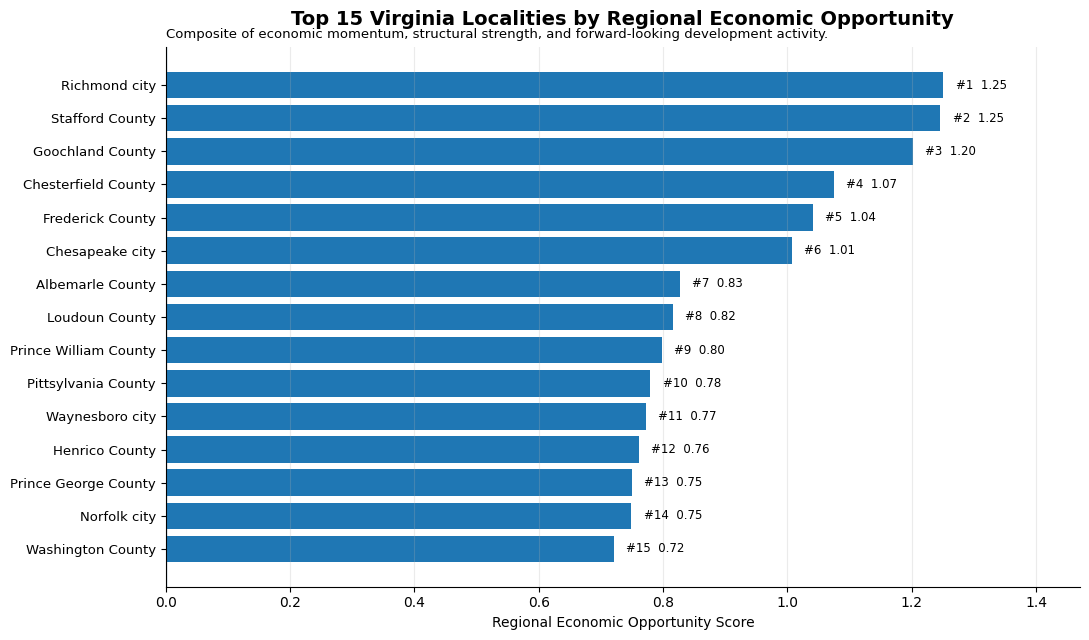

In [46]:
# Visualize the top 15 Regional Economic Opportunity scores
# in a more compact format for notebook display.
# ---------------------------------------------------------

top15_plot = (
    top15_opportunity
    .sort_values(
        "regional_opportunity_score",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

bars = ax.barh(
    top15_plot["locality_name"],
    top15_plot["regional_opportunity_score"]
)

# Add rank and score labels.
for bar, rank, score in zip(
    bars,
    top15_plot["opportunity_rank"],
    top15_plot["regional_opportunity_score"]
):

    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"#{int(rank)}  {score:.2f}",
        va="center",
        fontsize=8.5
    )

ax.set_xlabel(
    "Regional Economic Opportunity Score"
)

ax.set_ylabel("")

ax.set_title(
    "Top 15 Virginia Localities by Regional Economic Opportunity",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0,
    1.012,
    (
        "Composite of economic momentum, structural strength, "
        "and forward-looking development activity."
    ),
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom"
)

ax.axvline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="y",
    labelsize=9.5
)

ax.set_xlim(
    min(0, top15_plot["regional_opportunity_score"].min() - 0.1),
    top15_plot["regional_opportunity_score"].max() + 0.22
)

plt.tight_layout()

opportunity_ranking_figure_path = (
    OUTPUT_FIGURES
    / "regional_opportunity_top15_localities.png"
)

plt.savefig(
    opportunity_ranking_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 11.2 Regional Economic Profile Distribution

The composite ranking identifies overall opportunity, but the regional profile framework explains *why* localities differ.

The figure below shows how many eligible Virginia localities fall into each economic profile.

These profiles distinguish broad-based strength, investment-led renewal, momentum-led growth, structural resilience, and potential vulnerability.

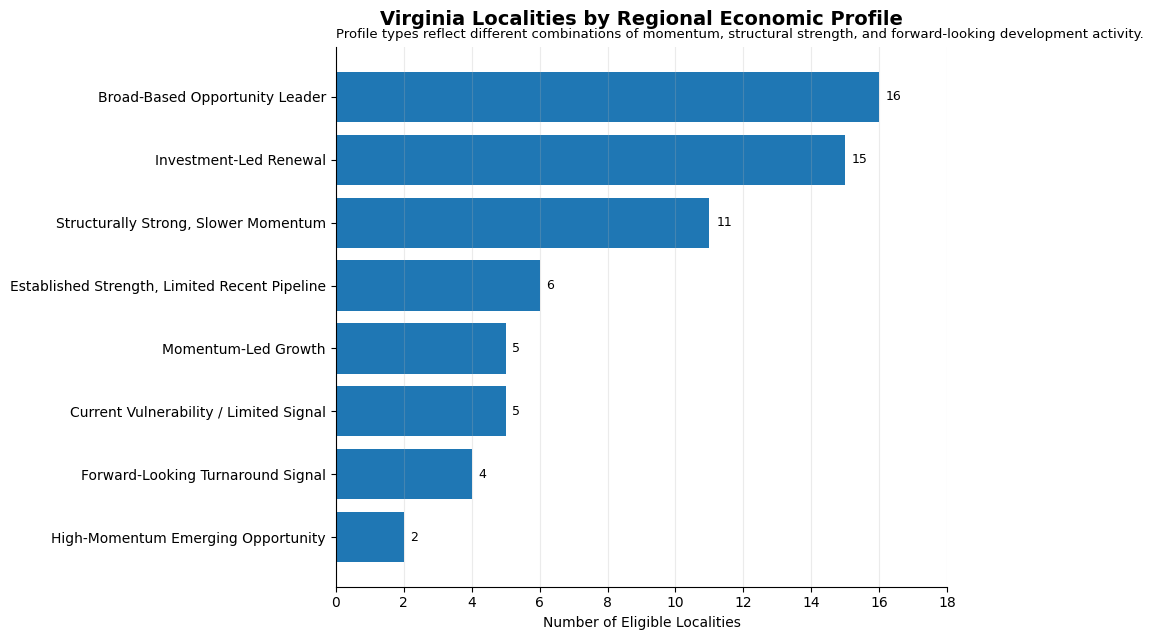

Saved figure: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures\regional_economic_profile_distribution.png


In [47]:
# Visualize the distribution of regional economic profiles.
# --------------------------------------------------------

profile_plot = (
    profile_summary
    .sort_values(
        "locality_count",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6.5)
)

bars = ax.barh(
    profile_plot["regional_economic_profile"],
    profile_plot["locality_count"]
)

# Add count labels.
for bar, count in zip(
    bars,
    profile_plot["locality_count"]
):

    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}",
        va="center",
        fontsize=9
    )

ax.set_xlabel(
    "Number of Eligible Localities"
)

ax.set_ylabel("")

ax.set_title(
    "Virginia Localities by Regional Economic Profile",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0,
    1.012,
    (
        "Profile types reflect different combinations of momentum, "
        "structural strength, and forward-looking development activity."
    ),
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom"
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(
    0,
    profile_plot["locality_count"].max() + 2
)

plt.tight_layout()

profile_figure_path = (
    OUTPUT_FIGURES
    / "regional_economic_profile_distribution.png"
)

plt.savefig(
    profile_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {profile_figure_path}"
)

### 11.3 Regional Opportunity Landscape

The profile categories can also be visualized as a continuous regional opportunity landscape.

The figure below compares:

- **Economic Momentum** on the horizontal axis;
- **Structural Strength** on the vertical axis;
- **Forward Development** through point size.

This makes it possible to see how localities differ across the three major dimensions of the framework rather than relying only on the final composite score.

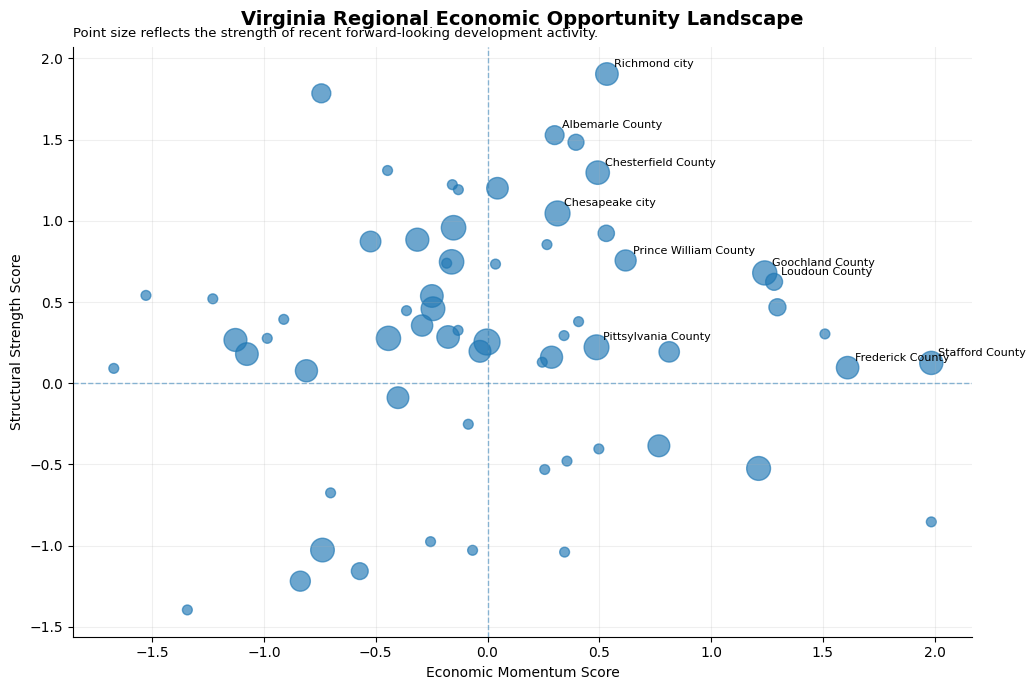

Saved figure: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures\regional_opportunity_landscape.png


In [48]:
# Visualize the three major dimensions of the Regional Economic
# Opportunity Framework in one integrated chart.
# -------------------------------------------------------------

landscape_data = (
    regional_base[
        regional_base["comprehensive_framework_eligible"]
    ]
    [
        [
            "locality_name",
            "economic_momentum_score_final",
            "structural_strength_score_final",
            "forward_development_score",
            "regional_opportunity_score"
        ]
    ]
    .copy()
)

# Convert the forward-development score into positive marker sizes.
# Scores are shifted so that even below-average localities remain visible.
forward_shifted = (
    landscape_data["forward_development_score"]
    - landscape_data["forward_development_score"].min()
)

marker_sizes = (
    50
    + 300
    * forward_shifted
    / max(forward_shifted.max(), 1)
)

fig, ax = plt.subplots(
    figsize=(10.5, 7)
)

ax.scatter(
    landscape_data["economic_momentum_score_final"],
    landscape_data["structural_strength_score_final"],
    s=marker_sizes,
    alpha=0.65
)

# Zero lines separate above- and below-average component scores.
ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.set_xlabel(
    "Economic Momentum Score"
)

ax.set_ylabel(
    "Structural Strength Score"
)

ax.set_title(
    "Virginia Regional Economic Opportunity Landscape",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0,
    1.012,
    (
        "Point size reflects the strength of recent forward-looking "
        "development activity."
    ),
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom"
)

# Label the 10 highest composite-score localities.
label_localities = (
    landscape_data
    .nlargest(
        10,
        "regional_opportunity_score"
    )
)

for _, row in label_localities.iterrows():

    ax.annotate(
        row["locality_name"],
        (
            row["economic_momentum_score_final"],
            row["structural_strength_score_final"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.grid(
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

opportunity_landscape_figure_path = (
    OUTPUT_FIGURES
    / "regional_opportunity_landscape.png"
)

plt.savefig(
    opportunity_landscape_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {opportunity_landscape_figure_path}"
)

## 12. Save Final Regional Opportunity Outputs

The final Regional Economic Opportunity Framework combines validated indicators from the historical QCEW analysis and the forward-looking VEDP document-intelligence workflow.

The outputs below preserve:

- the full 133-locality analytical base;
- the 64-locality comprehensive opportunity ranking;
- regional economic profile classifications;
- sensitivity-analysis results;
- and summary tables used in the final interpretation.

In [49]:
# Save the primary Notebook 05 analytical outputs.
# ------------------------------------------------

# 1. Full locality-level analytical base
regional_base.to_csv(
    OUTPUT_TABLES / "regional_economic_opportunity_framework_all_localities.csv",
    index=False
)

# 2. Eligible comprehensive ranking
regional_opportunity_ranking.to_csv(
    OUTPUT_TABLES / "regional_economic_opportunity_ranking.csv",
    index=False
)

# 3. Regional economic profiles
profile_characteristics.to_csv(
    OUTPUT_TABLES / "regional_economic_profile_summary.csv",
    index=False
)

# 4. Sensitivity analysis
sensitivity_summary.to_csv(
    OUTPUT_TABLES / "regional_opportunity_sensitivity_summary.csv",
    index=False
)

print("Saved Notebook 05 outputs:")
print(" - regional_economic_opportunity_framework_all_localities.csv")
print(" - regional_economic_opportunity_ranking.csv")
print(" - regional_economic_profile_summary.csv")
print(" - regional_opportunity_sensitivity_summary.csv")

Saved Notebook 05 outputs:
 - regional_economic_opportunity_framework_all_localities.csv
 - regional_economic_opportunity_ranking.csv
 - regional_economic_profile_summary.csv
 - regional_opportunity_sensitivity_summary.csv


## 13. Headline Findings

The Regional Economic Opportunity Framework reveals that Virginia localities can reach strong economic positions through different combinations of momentum, structural strength, and forward-looking development activity.

The summary below highlights the most important quantitative results from the final framework.

In [50]:
# Build a concise table of headline findings from Notebook 05.
# ------------------------------------------------------------

top_ranked = (
    regional_opportunity_ranking
    .iloc[0]
)

broad_based_count = (
    profile_summary.loc[
        profile_summary["regional_economic_profile"]
        .eq("Broad-Based Opportunity Leader"),
        "locality_count"
    ]
    .iloc[0]
)

investment_led_count = (
    profile_summary.loc[
        profile_summary["regional_economic_profile"]
        .eq("Investment-Led Renewal"),
        "locality_count"
    ]
    .iloc[0]
)

headline_findings_05 = pd.DataFrame([
    {
        "finding": "Localities in full analytical base",
        "value": len(regional_base),
        "interpretation": (
            "All Virginia localities remain represented in the final analytical dataset."
        )
    },
    {
        "finding": "Localities eligible for comprehensive ranking",
        "value": regional_base[
            "comprehensive_framework_eligible"
        ].sum(),
        "interpretation": (
            "These localities meet both the employment-base and "
            "industry-coverage quality thresholds."
        )
    },
    {
        "finding": "Highest-ranked locality",
        "value": top_ranked["locality_name"],
        "interpretation": (
            "The highest baseline opportunity score reflects the strongest "
            "combined performance across momentum, structure, and forward development."
        )
    },
    {
        "finding": "Broad-Based Opportunity Leaders",
        "value": broad_based_count,
        "interpretation": (
            "These localities score above average across all three major framework dimensions."
        )
    },
    {
        "finding": "Investment-Led Renewal localities",
        "value": investment_led_count,
        "interpretation": (
            "These localities combine weaker recent momentum with stronger "
            "structural foundations and recent development activity."
        )
    },
    {
        "finding": "Baseline vs. momentum-focused rank correlation",
        "value": round(
            sensitivity_summary.loc[
                sensitivity_summary["comparison"]
                .eq("Baseline vs. Momentum-Focused"),
                "spearman_rank_correlation"
            ].iloc[0],
            3
        ),
        "interpretation": (
            "The overall ranking remains highly stable when more weight is placed on momentum."
        )
    },
    {
        "finding": "Baseline vs. forward-focused rank correlation",
        "value": round(
            sensitivity_summary.loc[
                sensitivity_summary["comparison"]
                .eq("Baseline vs. Forward-Focused"),
                "spearman_rank_correlation"
            ].iloc[0],
            3
        ),
        "interpretation": (
            "The ranking also remains highly stable when recent development activity receives more weight."
        )
    }
])

headline_findings_05

,finding,value,interpretation
0,Localities in full analytical base,133,All Virginia localities remain represented in ...
1,Localities eligible for comprehensive ranking,64,These localities meet both the employment-base...
2,Highest-ranked locality,Richmond city,The highest baseline opportunity score reflect...
3,Broad-Based Opportunity Leaders,16,These localities score above average across al...
4,Investment-Led Renewal localities,15,These localities combine weaker recent momentu...
5,Baseline vs. momentum-focused rank correlation,0.983,The overall ranking remains highly stable when...
6,Baseline vs. forward-focused rank correlation,0.957,The ranking also remains highly stable when re...


In [51]:
# Display headline findings with wrapped interpretation text.
# -----------------------------------------------------------

(
    headline_findings_05
    .style
    .set_properties(
        subset=["finding"],
        **{
            "min-width": "260px",
            "text-align": "left"
        }
    )
    .set_properties(
        subset=["value"],
        **{
            "min-width": "140px",
            "text-align": "center"
        }
    )
    .set_properties(
        subset=["interpretation"],
        **{
            "min-width": "520px",
            "max-width": "650px",
            "white-space": "normal",
            "text-align": "left"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("vertical-align", "top")
            ]
        }
    ])
    .hide(axis="index")
)

finding,value,interpretation
Localities in full analytical base,133,All Virginia localities remain represented in the final analytical dataset.
Localities eligible for comprehensive ranking,64,These localities meet both the employment-base and industry-coverage quality thresholds.
Highest-ranked locality,Richmond city,"The highest baseline opportunity score reflects the strongest combined performance across momentum, structure, and forward development."
Broad-Based Opportunity Leaders,16,These localities score above average across all three major framework dimensions.
Investment-Led Renewal localities,15,These localities combine weaker recent momentum with stronger structural foundations and recent development activity.
Baseline vs. momentum-focused rank correlation,0.983000,The overall ranking remains highly stable when more weight is placed on momentum.
Baseline vs. forward-focused rank correlation,0.957000,The ranking also remains highly stable when recent development activity receives more weight.


In [52]:
# Save Notebook 05 headline findings.
# ------------------------------------

headline_findings_05.to_csv(
    OUTPUT_TABLES / "regional_opportunity_headline_findings.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_TABLES / "regional_opportunity_headline_findings.csv"
)

Saved: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\tables\regional_opportunity_headline_findings.csv


## 14. Answer to Research Question

### Research Question

> **Which Virginia localities show the strongest combination of recent economic momentum, competitive industry performance, structural economic strengths, and forward-looking development signals—and where do the data suggest emerging opportunities or vulnerabilities?**

### Answer

The final framework shows that regional opportunity in Virginia is multidimensional.

Among the 64 localities with sufficiently reliable data for comprehensive comparison, **Richmond city ranks first overall**, followed closely by **Stafford County, Goochland County, Chesterfield County, Frederick County, and Chesapeake city**.

These localities do not rank highly for the same reason.

- Richmond combines exceptional structural strength with solid momentum and strong recent development activity.
- Stafford ranks highly because of unusually strong recent momentum and a substantial forward-looking project pipeline.
- Goochland performs strongly across all three dimensions.
- Chesterfield combines strong structural conditions with meaningful recent development activity.
- Chesapeake benefits from a particularly strong forward-development signal alongside a broad and diversified economic structure.

The profile analysis shows that **16 localities qualify as Broad-Based Opportunity Leaders**, meaning they score above average in momentum, structural strength, and forward development.

Another **15 localities fall into the Investment-Led Renewal category**. These places have weaker recent momentum but stronger structural foundations and meaningful recent development activity, suggesting that new investment may be supporting economic renewal.

The analysis also identifies more specialized regional trajectories:

- High-Momentum Emerging Opportunity localities combine strong recent growth and development activity with weaker structural breadth.
- Momentum-Led Growth localities are performing well historically but have limited recent project activity.
- Forward-Looking Turnaround localities show weak historical conditions but meaningful new investment signals.
- Structurally Strong, Slower Momentum localities retain strong economic foundations despite weaker recent growth.
- Current Vulnerability / Limited Signal localities score below average across all three dimensions.

The sensitivity analysis indicates that these conclusions are not highly dependent on the exact component weights. The baseline ranking has a Spearman rank correlation of **0.983** with a momentum-focused alternative and **0.957** with a more forward-looking alternative.

Overall, the results suggest that Virginia's strongest regional opportunities are not defined by one factor alone. The most compelling localities combine recent economic performance, a diversified and specialized industry structure, and evidence of new investment or job creation.

## 15. Conclusion

This notebook transforms the earlier regional analysis into a transparent decision-support framework for comparing Virginia local economies.

The Regional Economic Opportunity Framework combines three dimensions:

- **Economic Momentum** — recent employment growth and competitive performance;
- **Structural Strength** — specialization breadth and industry diversification;
- **Forward Development** — recent announced investment, jobs, and project activity.

Several methodological safeguards were included to improve comparability:

- extreme growth and competitive-effect rates were winsorized;
- small employment bases were excluded from statewide momentum rankings;
- diversification scores were used only where sufficient industry data were published;
- extreme single-industry location quotients were not allowed to dominate the structural score;
- and alternative weighting scenarios were tested to evaluate sensitivity.

The resulting framework should not be interpreted as a forecast or as a definitive ranking of local economic quality. Instead, it provides a structured way to identify different forms of regional opportunity, strength, transition, and vulnerability.

Most importantly, the analysis shows the value of combining multiple forms of economic evidence.

Historical QCEW data reveal where employment and competitive performance have been strongest. Industry structure shows the foundations on which regional economies depend. VEDP announcements add a forward-looking signal of where new investment and job creation may be developing.

Together, these measures provide a richer and more policy-relevant picture of Virginia's regional economy than any single indicator can provide on its own.